# Chapter 14: What Doesn't Work

**When the hidden grouping matters to the label, how much of that value does a K-means column recover for a boosted-tree model?**

The chapter says K-means geometry need not align with the target, and asks for the addition to be compared with the original features and checked for stable assignments. This measures how that comparison comes out when the answer is known.

*Constructed data. The K-means gain is at most about 0.01 AUC, a few standard errors above zero at the middle settings, so the ordering between settings is not claimed; only that it stays far below the value of the true grouping.*

## The experiment

Constructed binary task: six hidden groups in eight dimensions whose centres sit a distance set by the control, and a label that depends on three features and on the group (group effect standard deviation 1.5 log odds). One scikit-learn histogram gradient boosting model scores AUC on 6,000 new rows with the original features, with a K-means column and distances (scaling and clusters fitted on the 800 training rows, six clusters), and with the true group id supplied directly; both group ids enter as native categorical columns. Stability is the agreement (adjusted Rand index) between clusterings fitted on two halves of the training rows; recovery is the agreement with the true groups. Sixteen independent datasets are averaged.

In [1]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import adjusted_rand_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

from kaggle_companion.activities._common import clean

SEED = 14
REPLICATES = 16              # independent constructed datasets; every estimate is their mean
GROUPS, DIM = 6, 8
N_TRAIN, N_NEW = 800, 6000
EFFECT_SD = 1.5              # how strongly the true group moves the log odds


def generate(spread, seed):
    """Six hidden groups in eight dimensions. The label depends on three features and on the hidden group."""
    rng = np.random.default_rng(seed)
    centers = rng.normal(0.0, spread, (GROUPS, DIM))               # `spread` sets how far apart the groups sit
    effect = rng.normal(size=GROUPS)
    effect = (effect - effect.mean()) / effect.std() * EFFECT_SD   # group effect on the log odds
    weights = np.array([0.7, -0.5, 0.4])

    def rows(n):
        group = rng.integers(0, GROUPS, n)
        X = centers[group] + rng.normal(size=(n, DIM))
        y = (rng.random(n) < 1 / (1 + np.exp(-(X[:, :3] @ weights + effect[group])))).astype(int)
        return X, y, group

    return rows(N_TRAIN), rows(N_NEW)


def booster(**extra):
    return HistGradientBoostingClassifier(max_iter=60, learning_rate=0.1, max_leaf_nodes=8, min_samples_leaf=15,
                                          random_state=0, **extra)


def cluster_features(X_fit, *others):
    """Scale and cluster on training rows only; return the training columns and the same columns for other rows."""
    scaler = StandardScaler().fit(X_fit)
    km = KMeans(GROUPS, n_init=5, random_state=0).fit(scaler.transform(X_fit))
    def build(X):
        Z = scaler.transform(X)
        return np.column_stack([X, km.predict(Z), km.transform(Z)])   # raw columns, cluster id, distance to each centre
    return [build(X_fit)] + [build(X) for X in others], km, scaler


def run(spread):
    gain_learned, gain_known, recovery, stability, base_auc = [], [], [], [], []
    for rep in range(REPLICATES):
        (X, y, g), (X_new, y_new, g_new) = generate(spread, SEED * 100 + rep)
        score = lambda model, a, b: roc_auc_score(y_new, model.fit(a, y).predict_proba(b)[:, 1])
        base = score(booster(), X, X_new)
        (F, F_new), km, scaler = cluster_features(X, X_new)
        gain_learned.append(score(booster(categorical_features=[DIM]), F, F_new) - base)   # K-means id learned from training rows
        gain_known.append(score(booster(categorical_features=[DIM]),               # the true group id, supplied directly
                                np.column_stack([X, g]), np.column_stack([X_new, g_new])) - base)
        recovery.append(adjusted_rand_score(g_new, km.predict(scaler.transform(X_new))))   # known only because the data are constructed
        half = N_TRAIN // 2                                                         # observable: do two halves agree on new rows?
        labels = []
        for part in (slice(0, half), slice(half, N_TRAIN)):
            half_scaler = StandardScaler().fit(X[part])
            half_km = KMeans(GROUPS, n_init=5, random_state=0).fit(half_scaler.transform(X[part]))
            labels.append(half_km.predict(half_scaler.transform(X_new)))
        stability.append(adjusted_rand_score(labels[0], labels[1]))
        base_auc.append(base)
    return clean({
        "spread": spread, "baseline_auc": float(np.mean(base_auc)),
        "gain_learned": float(np.mean(gain_learned)), "gain_known": float(np.mean(gain_known)),
        "recovery": float(np.mean(recovery)), "stability": float(np.mean(stability)),
        "standard_error_learned": float(np.std(gain_learned) / np.sqrt(REPLICATES)),
        "per_replicate": {"gain_learned": gain_learned, "gain_known": gain_known},
        "replicates": REPLICATES, "train_rows": N_TRAIN, "new_rows": N_NEW,
    })


## Measure it across the control

The control is **spread of the group centres (standard deviations of the within-group noise)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch14 import explain

VALUES = [0.4, 0.8, 1.2, 1.8]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                        0.4     0.8     1.2     1.8
Baseline AUC          0.685   0.768   0.815   0.855
K-means column gain  -0.001  +0.004  +0.010  +0.003
True group id gain   +0.143  +0.069  +0.028  +0.008
Stability (ARI)        0.16    0.62    0.88    0.98
Recovery (ARI)         0.10    0.49    0.80    0.96


## Look at it

The figure shows the default setting, spread of the group centres (standard deviations of the within-group noise) = 0.8.

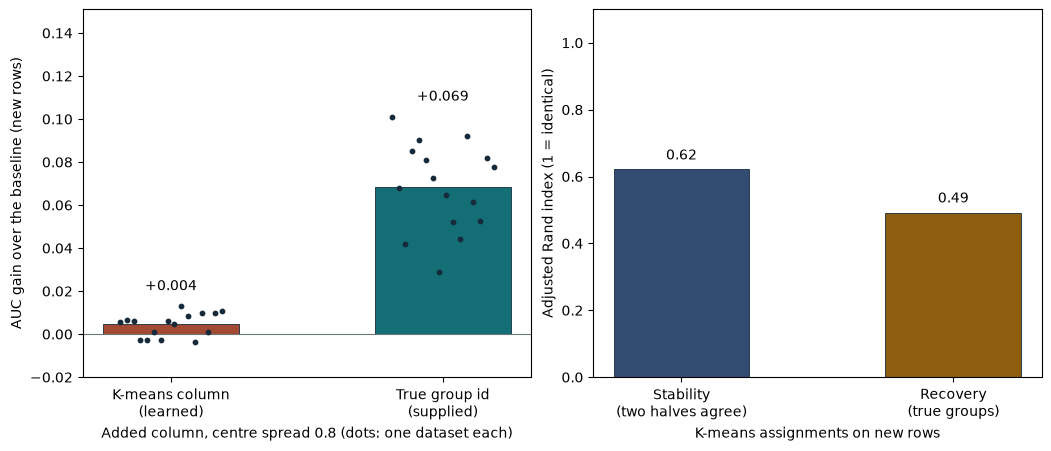

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch14 import draw, NCOLS, HEIGHT

DEFAULT = 0.8
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With centre spread 0.8, the true group id adds +0.069 AUC to the baseline of 0.768. The K-means column adds +0.004 (standard error 0.001), which is 7% of it, so 0.069 - 0.004 = 0.065 of the value stays out of reach. Two halves of the training rows agree on the clusters at ARI 0.62, and the clusters match the true groups at 0.49.

- Value of the true grouping: 0.837 - 0.768 = 0.069 AUC.
- Value of the K-means column: 0.773 - 0.768 = 0.005 AUC (standard error 0.001).
- Left out of reach: 0.069 - 0.004 = 0.065 AUC.

## Apply this to your competition

- Compare the K-means addition with the unchanged baseline on the same assessment rows, and report the paired difference with its spread.
- Fit scaling and clusters inside the training partition, and check that clusters from two training subsets agree before keeping the column.
- If a natural grouping exists, supply it directly as a categorical column rather than hoping clustering rediscovers it.
- Write the failure down as a scoped observation: data, scaling, k, base model and the gain, not as a ban on clustering features.

Book location: Chapter 14, K-Means Clustering as a Feature.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)